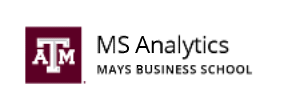

# ISTM 637 — Databricks Lakehouse Project · Starter Notebook
**MS Analytics · Texas A&M University · Mays Business School**

This notebook gets you to a consistent starting point: it creates your Unity Catalog
catalog/schema/volume, then hands ingestion of the three tables to a **Lakeflow
Declarative Pipeline**. After the pipeline runs, you come back here to add governance
tags and validate the star schema. **Later parts — Genie, the dashboard, the model,
the app, and OpenSharing — are described in the project handout.**

> **Run on Databricks Free Edition** using the serverless notebook compute.
> Check this notebook into your GitHub repo from a Git folder (see Part 1 of the handout).

---
### What this notebook does
1. Set your personal catalog/schema names (Part 2)
2. Create the catalog, schema, and a managed Volume for raw files
3. Hand off to the **Lakeflow pipeline** (`ISTM637_Lakeflow_Ingest_Pipeline.sql`), which
   uses `read_files()` to create `dim_well`, `dim_date`, `fact_production` in Unity Catalog
4. Add governance **tags** and spot-check the AI-generated column comments (Part 3)
5. Validate the star schema with a couple of SQL checks


## Part 2 — Set your names and create Unity Catalog objects

Free Edition gives every account **one workspace and one metastore**, so make your
catalog name unique to *you* (use your NetID) to avoid collisions when you later
share with teammates via OpenSharing.

In [ ]:
# --- EDIT THESE TWO LINES -------------------------------------------------
NETID   = "ismithard"                 # e.g. "jjohnston"
CATALOG = f"istm637_{NETID}"           # your personal catalog
SCHEMA  = "oilgas"                     # schema (database) for the star schema
VOLUME  = "raw"                        # managed volume to hold the uploaded CSVs
# -------------------------------------------------------------------------

VOL_PATH = f"/Volumes/{CATALOG}/{SCHEMA}/{VOLUME}"
print("Catalog :", CATALOG)
print("Schema  :", SCHEMA)
print("Volume  :", VOL_PATH)

In [ ]:
spark.sql(f"CREATE CATALOG IF NOT EXISTS {CATALOG} COMMENT 'ISTM 637 project catalog'")
spark.sql(f"CREATE SCHEMA  IF NOT EXISTS {CATALOG}.{SCHEMA} COMMENT 'Oil & gas star schema'")
spark.sql(f"CREATE VOLUME  IF NOT EXISTS {CATALOG}.{SCHEMA}.{VOLUME} COMMENT 'Raw uploaded CSVs'")
spark.sql(f"USE CATALOG {CATALOG}")
spark.sql(f"USE SCHEMA {SCHEMA}")
print("Created", CATALOG, "/", SCHEMA, "and volume", VOLUME)

## Part 2 (cont.) — Upload the CSV files to your Volume

The three CSVs were provided with this assignment:
`dim_well.csv`, `dim_date.csv`, `fact_production.csv`.

**Upload them into the Volume you just created:**
1. In the left sidebar open **Catalog** → expand `{CATALOG}` → `{SCHEMA}` → **Volumes** → `raw`.
2. Click **Upload to this volume** and add all three CSV files.

After uploading, run the next cell to confirm the files are present.

In [ ]:
# Confirm the three files are in the volume
files = [f.name for f in dbutils.fs.ls(VOL_PATH)]
print("Files in volume:", files)
expected = {"dim_well.csv", "dim_date.csv", "fact_production.csv"}
missing = expected - set(files)
assert not missing, f"Still need to upload: {missing}"
print("All three CSVs found ✔")

## Part 2 (cont.) — Ingest into Unity Catalog with Lakeflow

You do **not** load the tables from this notebook. Instead, a **Lakeflow Declarative
Pipeline** reads the CSVs from your volume with `read_files()` and creates the three
Unity Catalog tables. Do this now, then return here:

1. Open **`ISTM637_Lakeflow_Ingest_Pipeline.sql`** (provided with the assignment).
2. In the sidebar: **Jobs & Pipelines → Create → ETL pipeline**, choose **SQL**, and
   attach that file as the pipeline source.
3. In pipeline **Settings**, set **Default catalog** = `{CATALOG}`, **Default schema**
   = `{SCHEMA}`, and add a **Configuration** entry `source_path` = `{VOL_PATH}`.
4. Click **Run**. The pipeline materializes `dim_well`, `dim_date`, `fact_production`.

*(No-code alternative: build the same flows in **Lakeflow Designer**.)* Once the pipeline
run succeeds, run the cell below to confirm the tables landed in Unity Catalog.

In [ ]:
# Confirm the Lakeflow pipeline created the three tables in Unity Catalog
for t in ["dim_well", "dim_date", "fact_production"]:
    try:
        n = spark.table(f"{CATALOG}.{SCHEMA}.{t}").count()
        print(f"{t:18s} -> {n:>7,} rows  ✔")
    except Exception as e:
        print(f"{t:18s} -> NOT FOUND yet — run the Lakeflow pipeline first")
# Expected: ~50 wells, ~547 dates, ~22,800 production rows

## Part 3 — Add metadata with the AI assistant (this part is graded)

Metadata is what makes **Genie** answer well later. You will generate the **column
comments with the AI assistant in Catalog Explorer**:

1. Open **Catalog Explorer** → your catalog → schema → a table (start with `dim_well`).
2. Accept or edit the **AI-suggested table description**, then open the **Columns** tab and
   use **AI generate** to draft a comment for every column.
3. **Review before accepting** — fix units and domain terms the AI can't know
   (bbl, mcf, psi, choke in 64ths, water cut). Repeat for all three tables.

Here in the notebook you apply the governance **tags** and spot-check the comments.

In [ ]:
# ---- Governance tags (key/value) on each table --------------------------
# Tags are catalog metadata. If SET TAGS is not permitted on a pipeline-managed
# view in your workspace, add the same tags from Catalog Explorer instead.
tags = {
    "fact_production": "('domain'='production', 'layer'='silver', 'pii'='none')",
    # TODO (Part 3): add the two dimensions:
    # "dim_well": "('domain'='well_master', 'layer'='silver')",
    # "dim_date": "('domain'='calendar',    'layer'='silver')",
}
for tbl, kv in tags.items():
    try:
        spark.sql(f"ALTER TABLE {CATALOG}.{SCHEMA}.{tbl} SET TAGS {kv}")
        print(f"{tbl}: tags applied ✔")
    except Exception as e:
        print(f"{tbl}: could not SET TAGS here — add them in Catalog Explorer. ({str(e)[:80]})")

In [ ]:
# ---- Spot-check the AI-generated comments --------------------------------
# (Run after you accept the AI suggestions in Catalog Explorer. Every column
#  should show a comment; fix any blanks or wrong units back in the UI.)
for tbl in ["dim_well", "dim_date", "fact_production"]:
    df = spark.sql(f"DESCRIBE TABLE {CATALOG}.{SCHEMA}.{tbl}").toPandas()
    # keep only real column rows (skip blanks and '# ...' metadata section rows)
    cols = df[(df["col_name"].str.len() > 0) & (~df["col_name"].str.startswith("#"))]
    missing = cols[(cols["comment"].isna()) | (cols["comment"] == "")]["col_name"].tolist()
    print(f"{tbl:18s} -> {'all columns commented ✔' if not missing else 'missing comments: ' + str(missing)}")

### Note on keys for pipeline-managed tables

These tables are Lakeflow **materialized views**, so the pipeline owns their schema — declare
data-quality rules with `CONSTRAINT ... EXPECT` *inside the pipeline* (see the
`fact_production` example) rather than adding `PRIMARY KEY` / `FOREIGN KEY` from here.
To make the join structure explicit for Genie, describe the `well_id` and `date_id`
relationships in your **Genie Space instructions** in Part 4.

## Validate the star schema

A couple of sanity-check queries you can also reuse as **example queries in your Genie Space**.

In [ ]:
display(spark.sql(f"""
  SELECT w.basin,
         ROUND(SUM(f.oil_bbl))   AS total_oil_bbl,
         ROUND(SUM(f.gas_mcf))   AS total_gas_mcf,
         COUNT(DISTINCT f.well_id) AS wells
  FROM {CATALOG}.{SCHEMA}.fact_production f
  JOIN {CATALOG}.{SCHEMA}.dim_well w ON f.well_id = w.well_id
  GROUP BY w.basin
  ORDER BY total_oil_bbl DESC
"""))

In [ ]:
display(spark.sql(f"""
  SELECT d.quarter_name,
         ROUND(SUM(f.oil_bbl)) AS oil_bbl
  FROM {CATALOG}.{SCHEMA}.fact_production f
  JOIN {CATALOG}.{SCHEMA}.dim_date d ON f.date_id = d.date_id
  GROUP BY d.quarter_name, d.year, d.quarter
  ORDER BY d.year, d.quarter
"""))

---
## What's next (done in the UI / the model notebook — see the handout for full steps & rubric)

- **Part 4 · Genie Space** — from the sidebar's **Genie Spaces**, create a space over these
  three tables, add the example queries above as trusted queries, and write instructions.
- **Part 5 · AI/BI Dashboard** — build a dashboard on the same star schema with at least
  four visualizations (time series, comparison, KPI) and an interactive filter.
- **Part 6 · Prediction model** — in `ISTM637_Predictive_Model_Notebook.ipynb`, train a
  regressor on this data, register it in Unity Catalog with MLflow, and save a
  `well_forecast` table for the app.
- **Part 7 · Simple data app** — use Genie Code to deploy a lightweight app that shows a
  chosen well's production history and its forecast from `well_forecast`.
- **Part 8 · OpenSharing** — share your `dim_well` (or a view) with a teammate's
  metastore and consume theirs.

Commit and push your notebooks (and your screenshots / writeup) to GitHub before you submit.
